In [39]:
import pandas as pd
import os

# Verificar que los archivos están en la carpeta data
data_path = '../data'
archivos = os.listdir(data_path)
print("Archivos en la carpeta data:")
for archivo in archivos:
    print(f"  - {archivo}")

Archivos en la carpeta data:
  - COAMDATA_DESC.pdf
  - coa_2002.mdb
  - codebook.pdf
  - crude_oil_clean.csv
  - eda_propiedades_crudo.png
  - heatmap_correlaciones.png
  - Summary of Analyses.xls


In [40]:
# Leer el archivo Excel
df = pd.read_excel('../data/Summary of Analyses.xls')

# Ver las primeras filas
print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas:")
df.head()

Forma del dataset: (9076, 54)

Primeras 5 filas:


,LINK_DRV,LINK_SAM,LINK_REF,DLAB_CODE,SAMPLE_ID,STCNTCODE,STCTNAME,REGION_NO,CNTYCODE,CNTYNAME,...,DGN,KER_DISVOL,DKD,GASOIL_VOL,AVED,NON_LUBVOL,MED_LUBVOL,VIS_LUBVOL,RESDUM_VOL,SGRR
0,1,1,1,B,0,49.0,WYOMING,NaN,3.0,BIG HORN,...,0.524,17.0,0.000,0.0,0.000,9.5,0.0,0.0,31.5,0.843
1,2,2,2,B,1,49.0,WYOMING,NaN,45.0,WESTON,...,0.770,0.0,0.000,0.0,0.000,52.9,0.0,0.0,24.0,0.000
2,3,3,3,B,2,17.0,LOUISIANA,NaN,27.0,CLAIBORNE,...,0.754,9.6,0.813,5.9,0.828,29.9,6.6,0.0,27.1,0.000
3,4,4,4,B,3,35.0,OKLAHOMA,4.0,107.0,OKFUSKEE,...,0.000,15.7,0.000,0.0,0.000,28.2,0.0,0.0,25.1,0.000
4,5,5,5,B,5,35.0,OKLAHOMA,3.0,37.0,CREEK,...,0.746,3.7,0.820,13.1,0.848,13.7,5.8,2.0,38.6,0.000


In [41]:
# Ver todas las columnas y cuántos valores tienen
print("Columnas disponibles:")
print(df.columns.tolist())

print("\nValores no nulos por columna:")
print(df.isnull().sum().sort_values())

Columnas disponibles:
['LINK_DRV', 'LINK_SAM', 'LINK_REF', 'DLAB_CODE', 'SAMPLE_ID', 'STCNTCODE', 'STCTNAME', 'REGION_NO', 'CNTYCODE', 'CNTYNAME', 'FIELD_CODE', 'FIELD_NAME', 'AAPG_NO', 'GEO_AGE', 'FORM_CODE', 'FORM_NAME', 'FORM_CDMOD', 'FORM_NMOD', 'LITH_CODE', 'DEPTH_TOP', 'DEPTH_BOT', 'SGRAV_CRUD', 'API_CRUDE', 'POUR_PTSGN', 'POUR_POINT', 'CRN', 'CRN_SIGN', 'SUA77', 'SU77', 'SUA100', 'SU100', 'S_YEAR', 'COLOUR', 'NRES_SIGN', 'NRES', 'SRES_SIGN', 'SRES', 'SRC_SIGN', 'SRC', 'CAR_RES_WT', 'CAR_CR_WT', 'LT_GAS_VOL', 'DLG', 'GAS_NP_VOL', 'DGN', 'KER_DISVOL', 'DKD', 'GASOIL_VOL', 'AVED', 'NON_LUBVOL', 'MED_LUBVOL', 'VIS_LUBVOL', 'RESDUM_VOL', 'SGRR']

Valores no nulos por columna:
LINK_DRV         0
LINK_SAM         0
LINK_REF         0
DLAB_CODE        0
SAMPLE_ID        0
FORM_CODE        0
FIELD_CODE       0
FIELD_NAME       0
FORM_NAME        0
GEO_AGE          0
LITH_CODE        0
FORM_CDMOD       0
S_YEAR           0
LT_GAS_VOL       0
CAR_RES_WT       0
COLOUR           0
NON_LUBVO

In [42]:
# Seleccionar columnas relevantes para el proyecto
columnas_clave = [
    'STCTNAME',      # Estado/País de origen
    'FIELD_NAME',    # Nombre del campo petrolero
    'API_CRUDE',     # Gravedad API (clasificación del crudo)
    'SGRAV_CRUD',    # Gravedad específica
    'SRC',           # Contenido de azufre en crudo (%)
    'CRN',           # Contenido de nitrógeno (%)
    'SU100',         # Viscosidad a 100°F (Saybolt)
    'SU77',          # Viscosidad a 77°F (Saybolt)
    'POUR_POINT',    # Punto de fluidez (°F)
    'CAR_CR_WT',     # Residuo de carbono (%)
    'LT_GAS_VOL',    # Volumen % gasolina ligera
    'GAS_NP_VOL',    # Volumen % gasolina y nafta
    'RESDUM_VOL',    # Volumen % residuo
]

df_clean = df[columnas_clave].copy()

print("Dataset filtrado:", df_clean.shape)
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())
print("\nEstadísticas básicas:")
df_clean.describe()

Dataset filtrado: (9076, 13)

Valores nulos por columna:
STCTNAME      3
FIELD_NAME    0
API_CRUDE     2
SGRAV_CRUD    2
SRC           2
CRN           2
SU100         3
SU77          5
POUR_POINT    3
CAR_CR_WT     0
LT_GAS_VOL    0
GAS_NP_VOL    0
RESDUM_VOL    0
dtype: int64

Estadísticas básicas:


,API_CRUDE,SGRAV_CRUD,SRC,CRN,SU100,SU77,POUR_POINT,CAR_CR_WT,LT_GAS_VOL,GAS_NP_VOL,RESDUM_VOL
count,9074.000000,9074.000000,9074.000000,9074.000000,9073.000000,9071.000000,9073.000000,9076.000000,9076.000000,9076.000000,9076.000000
mean,35.838054,1.107416,0.598242,0.049976,200.373636,17.356631,11.416180,2.064896,7.922609,28.499956,24.750948
std,8.885760,3.524710,0.888161,0.098697,809.286397,98.905910,17.571793,2.306013,6.492490,14.961165,12.559806
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.300000,0.821000,0.120000,0.000000,37.000000,0.000000,0.000000,0.500000,3.400000,19.800000,17.400000
50%,37.000000,0.841000,0.230000,0.001000,43.000000,0.000000,5.000000,1.400000,7.500000,29.300000,23.200000
75%,40.900000,0.871000,0.610000,0.066000,58.000000,0.000000,10.000000,2.700000,11.000000,35.600000,30.700000
max,72.400000,90.000000,13.080000,0.955000,21794.000000,6000.000000,230.000000,19.300000,83.200000,97.000000,83.700000


In [43]:
# Limpiar datos y crear variable objetivo
df_clean = df_clean.dropna().copy()

# Crear clasificación de tipo de crudo según API (norma estándar de la industria)
def clasificar_crudo(api):
    if api > 31.1:
        return 'Liviano'
    elif api >= 22.3:
        return 'Mediano'
    elif api >= 10:
        return 'Pesado'
    else:
        return 'Extra pesado'

df_clean['TIPO_CRUDO'] = df_clean['API_CRUDE'].apply(clasificar_crudo)

# Ver distribución de clases
print("Distribución de tipos de crudo:")
print(df_clean['TIPO_CRUDO'].value_counts())
print(f"\nTotal muestras limpias: {len(df_clean)}")

# Ver algunos ejemplos por tipo
print("\nEjemplos por categoría:")
df_clean.groupby('TIPO_CRUDO')['API_CRUDE'].describe()

Distribución de tipos de crudo:
TIPO_CRUDO
Liviano         6813
Mediano         1480
Pesado           762
Extra pesado      14
Name: count, dtype: int64

Total muestras limpias: 9069

Ejemplos por categoría:


,count,mean,std,min,25%,50%,75%,max
TIPO_CRUDO,,,,,,,,
Extra pesado,14.0,7.028571,2.494125,0.0,6.425,7.55,8.45,9.7
Liviano,6813.0,39.727580,5.922877,31.3,35.800,38.80,42.10,72.4
Mediano,1480.0,27.298784,2.605691,22.3,25.200,27.70,29.70,31.1
Pesado,762.0,18.242388,3.152839,10.0,15.700,19.20,20.80,22.1


In [44]:
# Guardar dataset limpio como CSV
df_clean.to_csv('../data/crude_oil_clean.csv', index=False)
print("Dataset guardado en data/crude_oil_clean.csv")
print(f"Filas: {len(df_clean)} | Columnas: {df_clean.shape[1]}")

Dataset guardado en data/crude_oil_clean.csv
Filas: 9069 | Columnas: 14


C:\Users\tomas\AppData\Local\Temp\ipykernel_764\1167001871.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='TIPO_CRUDO', y='API_CRUDE',
C:\Users\tomas\AppData\Local\Temp\ipykernel_764\1167001871.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='TIPO_CRUDO', y='SRC',


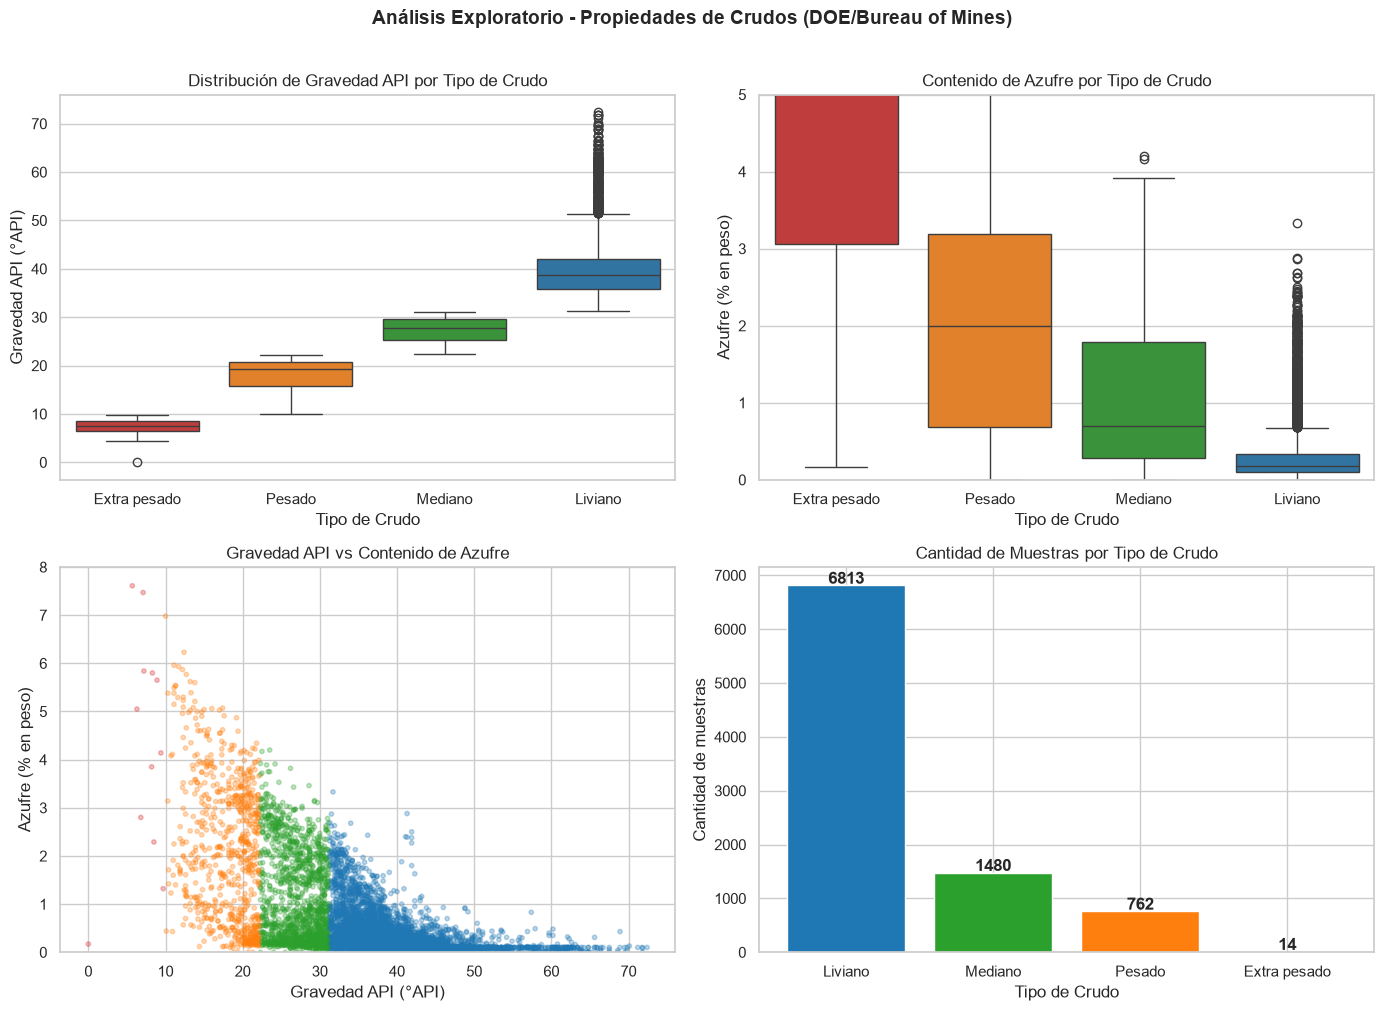

Gráfico guardado.


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio - Propiedades de Crudos (DOE/Bureau of Mines)', 
             fontsize=14, fontweight='bold', y=1.01)

# 1. Distribución de gravedad API por tipo de crudo
sns.boxplot(data=df_clean, x='TIPO_CRUDO', y='API_CRUDE', 
            order=['Extra pesado', 'Pesado', 'Mediano', 'Liviano'],
            palette=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'],
            ax=axes[0,0])
axes[0,0].set_title('Distribución de Gravedad API por Tipo de Crudo')
axes[0,0].set_xlabel('Tipo de Crudo')
axes[0,0].set_ylabel('Gravedad API (°API)')

# 2. Contenido de azufre por tipo de crudo
sns.boxplot(data=df_clean, x='TIPO_CRUDO', y='SRC',
            order=['Extra pesado', 'Pesado', 'Mediano', 'Liviano'],
            palette=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'],
            ax=axes[0,1])
axes[0,1].set_title('Contenido de Azufre por Tipo de Crudo')
axes[0,1].set_xlabel('Tipo de Crudo')
axes[0,1].set_ylabel('Azufre (% en peso)')
axes[0,1].set_ylim(0, 5)

# 3. Relación API vs Azufre
scatter = axes[1,0].scatter(df_clean['API_CRUDE'], df_clean['SRC'],
                             c=df_clean['TIPO_CRUDO'].map({
                                 'Liviano': '#1f77b4', 'Mediano': '#2ca02c',
                                 'Pesado': '#ff7f0e', 'Extra pesado': '#d62728'}),
                             alpha=0.3, s=10)
axes[1,0].set_title('Gravedad API vs Contenido de Azufre')
axes[1,0].set_xlabel('Gravedad API (°API)')
axes[1,0].set_ylabel('Azufre (% en peso)')
axes[1,0].set_ylim(0, 8)

# 4. Distribución de muestras por tipo
conteo = df_clean['TIPO_CRUDO'].value_counts()
axes[1,1].bar(conteo.index, conteo.values,
              color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
axes[1,1].set_title('Cantidad de Muestras por Tipo de Crudo')
axes[1,1].set_xlabel('Tipo de Crudo')
axes[1,1].set_ylabel('Cantidad de muestras')
for i, v in enumerate(conteo.values):
    axes[1,1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/eda_propiedades_crudo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

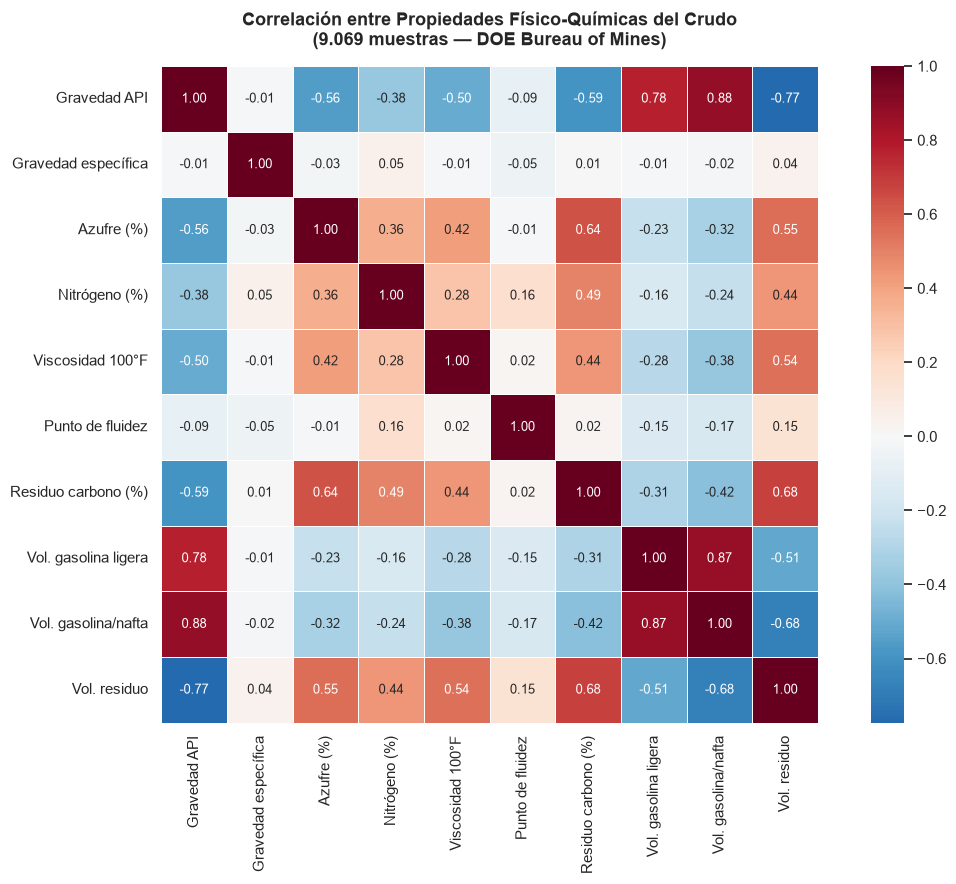

Heatmap guardado.


In [46]:
# Heatmap de correlaciones entre propiedades físico-químicas
columnas_numericas = ['API_CRUDE', 'SGRAV_CRUD', 'SRC', 'CRN', 
                      'SU100', 'POUR_POINT', 'CAR_CR_WT', 
                      'LT_GAS_VOL', 'GAS_NP_VOL', 'RESDUM_VOL']

nombres_legibles = {
    'API_CRUDE': 'Gravedad API',
    'SGRAV_CRUD': 'Gravedad específica',
    'SRC': 'Azufre (%)',
    'CRN': 'Nitrógeno (%)',
    'SU100': 'Viscosidad 100°F',
    'POUR_POINT': 'Punto de fluidez',
    'CAR_CR_WT': 'Residuo carbono (%)',
    'LT_GAS_VOL': 'Vol. gasolina ligera',
    'GAS_NP_VOL': 'Vol. gasolina/nafta',
    'RESDUM_VOL': 'Vol. residuo'
}

df_corr = df_clean[columnas_numericas].rename(columns=nombres_legibles)

# Filtrar outliers extremos para mejor visualización
df_corr = df_corr[df_corr['Viscosidad 100°F'] < 2000]

fig, ax = plt.subplots(figsize=(12, 9))
matriz_corr = df_corr.corr()

sns.heatmap(matriz_corr, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlación entre Propiedades Físico-Químicas del Crudo\n(9.069 muestras — DOE Bureau of Mines)', 
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap guardado.")

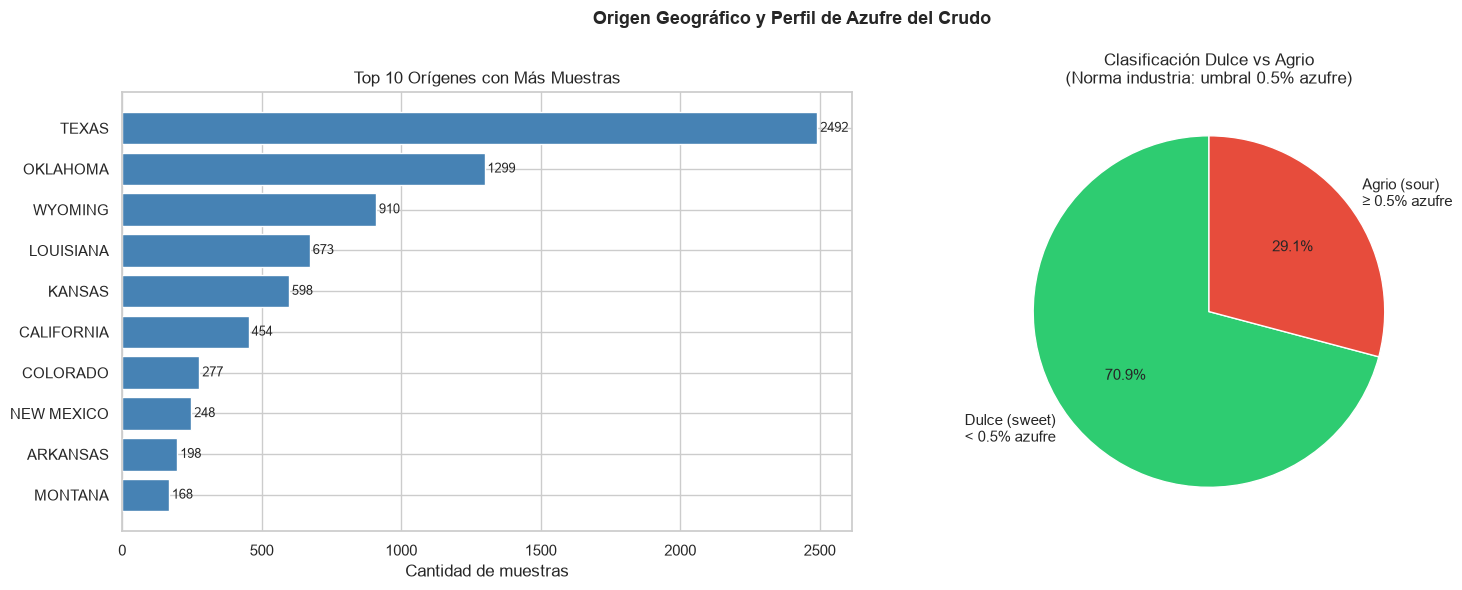

Gráfico guardado.


In [47]:
# Distribución geográfica - Top 10 estados/países con más muestras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Origen Geográfico y Perfil de Azufre del Crudo', 
             fontsize=13, fontweight='bold')

# Top 10 orígenes
top_origenes = df_clean['STCTNAME'].value_counts().head(10)
axes[0].barh(top_origenes.index[::-1], top_origenes.values[::-1], 
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Orígenes con Más Muestras')
axes[0].set_xlabel('Cantidad de muestras')
for i, v in enumerate(top_origenes.values[::-1]):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Clasificación dulce vs agrio (estándar industria: <0.5% = dulce)
df_clean['CLASE_AZUFRE'] = df_clean['SRC'].apply(
    lambda x: 'Dulce (sweet)\n< 0.5% azufre' if x < 0.5 else 'Agrio (sour)\n≥ 0.5% azufre'
)
conteo_azufre = df_clean['CLASE_AZUFRE'].value_counts()
colores = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    conteo_azufre.values,
    labels=conteo_azufre.index,
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Clasificación Dulce vs Agrio\n(Norma industria: umbral 0.5% azufre)')

plt.tight_layout()
plt.savefig('../data/eda_geografia_azufre.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")